# Libraries

In [ ]:
## Python Libraries and Dependencies
## Libraries for data handling and data preparation
import pandas as pd
import io
import numpy as np
from numpy import dtype

## Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Libraries for data preparation and hypertuning
from sklearn.model_selection import train_test_split, GridSearchCV

## Libraries for built in Model definitions
from sklearn.tree import DecisionTreeClassifier,  plot_tree
from sklearn.ensemble import RandomForestClassifier

## Libraries for model evaluation and feature evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import mutual_info_classif

# Data Preprocessing



In [ ]:
## Load the dataset
cust_churn = pd.read_csv("/content/customer_churn.csv")
cust_churn.head(10)

,CustomerID,Age,Subscription_Length_Months,Watch_Time_Hours,Number_of_Logins,Payment_Issues,Number_of_Complaints,Resolution_Time_Days,Membership_Type,Payment_Method,Preferred_Content_Type,Churn
0,1,56,35,157.957600,59,0,1,4,Standard,Debit,Movies,0
1,2,69,15,93.515499,26,0,3,1,Basic,Debit,TV Shows,0
2,3,46,25,87.095143,57,1,6,15,Premium,PayPal,Movies,1
3,4,32,28,113.986323,12,0,4,13,Standard,Credit Card,Sports,0
4,5,60,10,101.534816,11,1,5,8,Basic,Credit Card,Movies,1
5,6,25,17,166.093304,37,1,1,25,Standard,Credit Card,Sports,1
6,7,38,22,79.929269,25,0,2,4,Standard,Credit Card,Movies,1
7,8,56,26,122.738855,18,0,6,10,Basic,PayPal,Movies,1
8,9,36,25,221.841933,19,1,1,19,Standard,Debit,TV Shows,1
9,10,40,17,136.522261,23,0,5,18,Standard,Debit,Movies,1


In [ ]:
for i in cust_churn.columns:
  print("Column Name: ", i, ", Data Type: ", dtype(cust_churn[i]), ", Unique Values: ", len(cust_churn[i].unique()))

Column Name:  CustomerID , Data Type:  int64 , Unique Values:  1000
Column Name:  Age , Data Type:  int64 , Unique Values:  52
Column Name:  Subscription_Length_Months , Data Type:  int64 , Unique Values:  35
Column Name:  Watch_Time_Hours , Data Type:  float64 , Unique Values:  1000
Column Name:  Number_of_Logins , Data Type:  int64 , Unique Values:  59
Column Name:  Payment_Issues , Data Type:  int64 , Unique Values:  2
Column Name:  Number_of_Complaints , Data Type:  int64 , Unique Values:  10
Column Name:  Resolution_Time_Days , Data Type:  int64 , Unique Values:  29
Column Name:  Membership_Type , Data Type:  object , Unique Values:  3
Column Name:  Payment_Method , Data Type:  object , Unique Values:  3
Column Name:  Preferred_Content_Type , Data Type:  object , Unique Values:  3
Column Name:  Churn , Data Type:  int64 , Unique Values:  2


In [ ]:
## Converting Age column into ranges and each range into an integer
cust_churn.loc[cust_churn['Age'] < 20, 'Age'] = 1
cust_churn.loc[(cust_churn['Age'] >= 20) & (cust_churn['Age'] < 30), 'Age'] = 2
cust_churn.loc[(cust_churn['Age'] >= 30) & (cust_churn['Age'] < 40), 'Age'] = 3
cust_churn.loc[(cust_churn['Age'] >= 40) & (cust_churn['Age'] < 50), 'Age'] = 4
cust_churn.loc[(cust_churn['Age'] >= 50) & (cust_churn['Age'] < 60), 'Age'] = 5
cust_churn.loc[(cust_churn['Age'] >= 60) & (cust_churn['Age'] < 70), 'Age'] = 6



In [ ]:
## Converting Watch_Time_Hours column into ranges and each range into an integer, intervals of 50
cust_churn.loc[cust_churn['Watch_Time_Hours'] < 51, 'Watch_Time_Hours'] = 1
cust_churn.loc[(cust_churn['Watch_Time_Hours'] >= 51 ) & (cust_churn['Watch_Time_Hours'] < 100), 'Watch_Time_Hours'] = 2
cust_churn.loc[(cust_churn['Watch_Time_Hours'] >= 100) & (cust_churn['Watch_Time_Hours'] < 150), 'Watch_Time_Hours'] = 3
cust_churn.loc[(cust_churn['Watch_Time_Hours'] >= 150) & (cust_churn['Watch_Time_Hours'] < 200), 'Watch_Time_Hours'] = 4
cust_churn.loc[(cust_churn['Watch_Time_Hours'] >= 200) & (cust_churn['Watch_Time_Hours'] < 250), 'Watch_Time_Hours'] = 5


In [ ]:
## Converting Payment_method into 3 types
cust_churn.loc[cust_churn['Payment_Method'] == 'Credit Card', 'Payment_Method'] =  1
cust_churn.loc[cust_churn['Payment_Method'] == 'Debit', 'Payment_Method'] =  2
cust_churn.loc[cust_churn['Payment_Method'] == 'PayPal', 'Payment_Method'] =  3

In [ ]:
## Converting Preferred_Content_Type into 3 different types
cust_churn.loc[cust_churn['Preferred_Content_Type'] == 'Movies', 'Preferred_Content_Type'] = 1
cust_churn.loc[cust_churn['Preferred_Content_Type'] == 'TV Shows', 'Preferred_Content_Type'] = 2
cust_churn.loc[cust_churn['Preferred_Content_Type'] == 'Sports', 'Preferred_Content_Type'] = 3

In [ ]:
## Converting Membership_Type intp 3 different types
cust_churn.loc[cust_churn['Membership_Type'] == 'Basic', 'Membership_Type'] = 1
cust_churn.loc[cust_churn['Membership_Type'] == 'Standard', 'Membership_Type'] = 2
cust_churn.loc[cust_churn['Membership_Type'] == 'Premium', 'Membership_Type'] = 3

In [ ]:
cust_churn.head(10)

,CustomerID,Age,Subscription_Length_Months,Watch_Time_Hours,Number_of_Logins,Payment_Issues,Number_of_Complaints,Resolution_Time_Days,Membership_Type,Payment_Method,Preferred_Content_Type,Churn
0,1,5,35,4.0,59,0,1,4,2,2,1,0
1,2,6,15,2.0,26,0,3,1,1,2,2,0
2,3,4,25,2.0,57,1,6,15,3,3,1,1
3,4,3,28,3.0,12,0,4,13,2,1,3,0
4,5,6,10,3.0,11,1,5,8,1,1,1,1
5,6,2,17,4.0,37,1,1,25,2,1,3,1
6,7,3,22,2.0,25,0,2,4,2,1,1,1
7,8,5,26,3.0,18,0,6,10,1,3,1,1
8,9,3,25,5.0,19,1,1,19,2,2,2,1
9,10,4,17,3.0,23,0,5,18,2,2,1,1


# Model Training
1. Decision Tree Model Training and Hypertuning
2. Decision Tree Model Evaluation
3. Random Forest Model Training and Hypertuning
4. Random Forest Model Evaluation




## Decision Tree Model Training and Hyperparameter Tuning

In [ ]:
## Dataset Split
X = cust_churn.drop(['Churn', 'CustomerID'], axis=1)
y = cust_churn['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
## GridSearch for Desicion Tree
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

## Parameter Grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1, 2, 3, 4, 5],
    'min_samples_split': [2, 3, 4, 5],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search1 = GridSearchCV(
    estimator=decision_tree_classifier,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
)


grid_search1.fit(X_train, y_train)

print("Best Parameters:", grid_search1.best_params_)
print("Best Score:", grid_search1.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 2}
Best Score: 0.8371428571428572


##Decision Tree Model Evaluation



In [ ]:
## Model evaluation with metrics accuracy, precision, recall, F1_score, and confusion matrix
y_pred = grid_search1.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.85
Precision: 0.8784313725490196
Recall: 0.9411764705882353
F1 Score: 0.9087221095334685
Confusion Matrix:
 [[ 31  31]
 [ 14 224]]


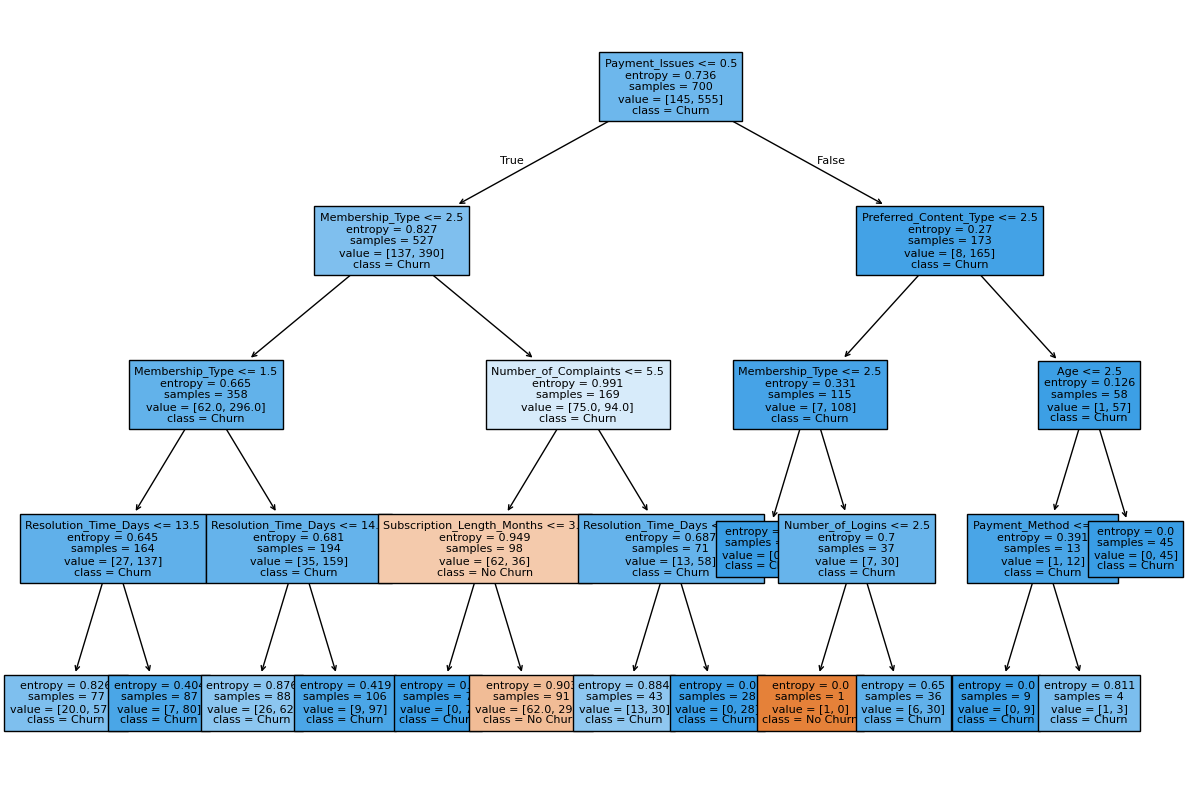

In [ ]:
## Visualizing the tree
plt.figure(figsize=(15, 10))
plot_tree(grid_search1.best_estimator_, feature_names = X.columns, class_names=['No Churn', 'Churn'], filled=True, fontsize=8)
plt.show()

## Random Forest Model Training and Hyperparameter Tuning

In [ ]:
## RandomForest Classifier
rdm_forest_classifier= RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid2 = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid search with 5-fold cross-validation
grid_search2 = GridSearchCV(
    estimator=rdm_forest_classifier,
    param_grid=param_grid2,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search2.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search2.best_params_)
print("Best Score:", grid_search2.best_score_)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Best Score: 0.8428571428571429


##Random Forest Model Evaluation


In [ ]:
## Model evaluation for test set using again accuracy, precision, recall, F1_score, and confusion matrix
y_pred = grid_search2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.8433333333333334
Precision: 0.8603773584905661
Recall: 0.957983193277311
F1 Score: 0.9065606361829026
Confusion Matrix:
 [[ 25  37]
 [ 10 228]]


# Feature Evaluation
1. Gini Index
2. Information Gain
3. Feature Importance using .feature_importances_

In [ ]:
## Determining gini index of all features/attributes/columns
def gini_index(feature):
    unique_values, counts = np.unique(feature, return_counts=True)
    probabilities = counts / len(feature)
    gini = 1 - np.sum(probabilities**2)
    return gini

print("="*60)
print("FEATURE SIGNIFICANCE FOR DECISION TREE USING GINI INDEX")
print("="*60)
for feature in X.columns:
    gini = gini_index(cust_churn[feature])
    print(f"Gini Index for {feature}: {gini:.2f}")
    print("-"*60)

FEATURE SIGNIFICANCE FOR DECISION TREE USING GINI INDEX
Gini Index for Age: 0.81
------------------------------------------------------------
Gini Index for Subscription_Length_Months: 0.97
------------------------------------------------------------
Gini Index for Watch_Time_Hours: 0.66
------------------------------------------------------------
Gini Index for Number_of_Logins: 0.98
------------------------------------------------------------
Gini Index for Payment_Issues: 0.37
------------------------------------------------------------
Gini Index for Number_of_Complaints: 0.90
------------------------------------------------------------
Gini Index for Resolution_Time_Days: 0.96
------------------------------------------------------------
Gini Index for Membership_Type: 0.67
------------------------------------------------------------
Gini Index for Payment_Method: 0.67
------------------------------------------------------------
Gini Index for Preferred_Content_Type: 0.66
---------

In [ ]:
## Determining information gain of all features/attributes/columns
print("="*60)
print("FEATURE SIGNIFICANCE FOR DECISION TREE USING INFORMATION GAIN")
print("="*60)
for feature in X.columns:
    info_gain = mutual_info_classif(cust_churn[[feature]], cust_churn['Churn'])
    print(f"Information Gain for {feature}: {info_gain}")
    print("-"*60)


FEATURE SIGNIFICANCE FOR DECISION TREE USING INFORMATION GAIN
Information Gain for Age: [0.00779451]
------------------------------------------------------------
Information Gain for Subscription_Length_Months: [0]
------------------------------------------------------------
Information Gain for Watch_Time_Hours: [0.00267355]
------------------------------------------------------------
Information Gain for Number_of_Logins: [0]
------------------------------------------------------------
Information Gain for Payment_Issues: [0.03945264]
------------------------------------------------------------
Information Gain for Number_of_Complaints: [0.08665788]
------------------------------------------------------------
Information Gain for Resolution_Time_Days: [0.02622524]
------------------------------------------------------------
Information Gain for Membership_Type: [0.01918175]
------------------------------------------------------------
Information Gain for Payment_Method: [0.02562619]


In [ ]:
## Feature significance extracted from decision tree model and random forest model
print("="*60)
print("FEATURE SIGNIFICANCE FOR DECISION TREE")
print("="*60)
for feature, importance in zip(X.columns, grid_search1.best_estimator_.feature_importances_):
    print(f"Feature: {feature}, Importance: {importance:.2f}")
    print("-"*60)
print("="*60)
print("FEATURE SIGNIFICANCE FOR RANDOM FOREST")
print("="*60)
for feature, importance in zip(X.columns, grid_search2.best_estimator_.feature_importances_):
    print(f"Feature: {feature}, Importance: {importance:.2f}")
    print("-"*60)

FEATURE SIGNIFICANCE FOR DECISION TREE
Feature: Age, Importance: 0.01
------------------------------------------------------------
Feature: Subscription_Length_Months, Importance: 0.07
------------------------------------------------------------
Feature: Watch_Time_Hours, Importance: 0.00
------------------------------------------------------------
Feature: Number_of_Logins, Importance: 0.02
------------------------------------------------------------
Feature: Payment_Issues, Importance: 0.22
------------------------------------------------------------
Feature: Number_of_Complaints, Importance: 0.17
------------------------------------------------------------
Feature: Resolution_Time_Days, Importance: 0.19
------------------------------------------------------------
Feature: Membership_Type, Importance: 0.29
------------------------------------------------------------
Feature: Payment_Method, Importance: 0.01
------------------------------------------------------------
Feature: Preferr

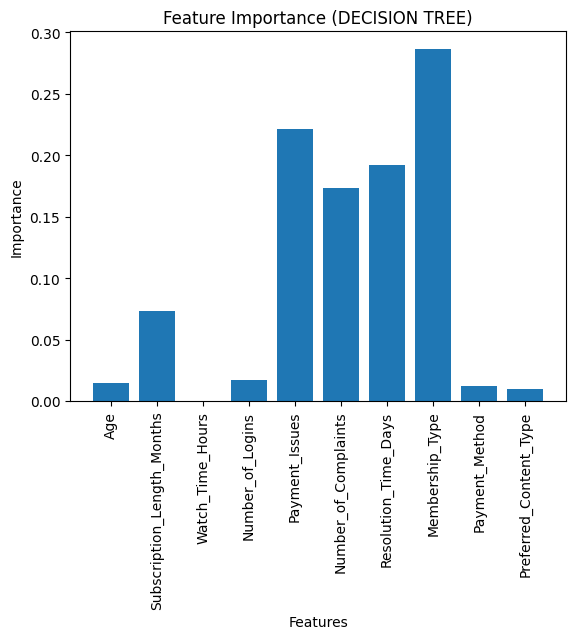

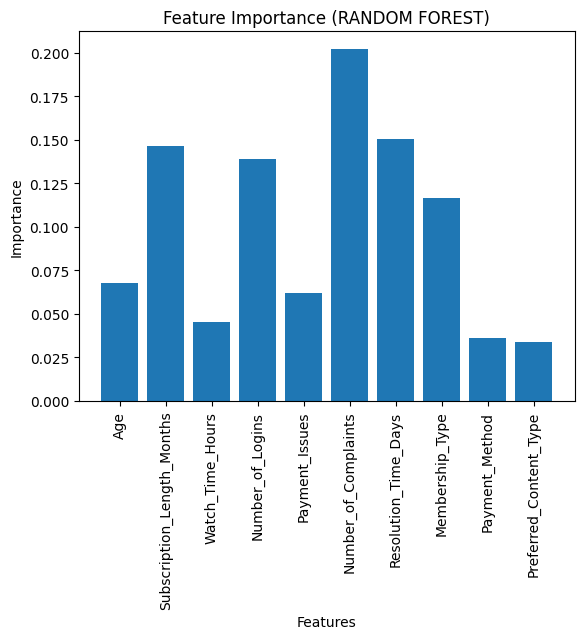

In [ ]:
## Visualize the feature importance in a bar plot, for Decision Tree Model
plt.bar(X.columns, grid_search1.best_estimator_.feature_importances_)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance (DECISION TREE)')
plt.xticks(rotation=90)
plt.show()

## Visualize the feature importance in a bar plot, for Random Forest Model
plt.bar(X.columns, grid_search2.best_estimator_.feature_importances_)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance (RANDOM FOREST)')
plt.xticks(rotation=90)
plt.show()

# Exploratory Data Analysis


In [ ]:
## Load the dataset again
cust_churn = pd.read_csv("/content/customer_churn.csv")

In [ ]:
cust_churn.describe()

,CustomerID,Age,Subscription_Length_Months,Watch_Time_Hours,Number_of_Logins,Payment_Issues,Number_of_Complaints,Resolution_Time_Days,Churn
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,18.218000,120.750899,30.984000,0.245000,4.552000,14.978000,0.793000
std,288.819436,14.99103,10.177822,38.583580,17.562237,0.430302,2.912349,8.394521,0.405358
min,1.000000,18.00000,1.000000,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,250.750000,31.00000,9.000000,93.630672,16.750000,0.000000,2.000000,7.000000,1.000000
50%,500.500000,44.00000,18.000000,122.085008,31.000000,0.000000,5.000000,15.000000,1.000000
75%,750.250000,56.00000,27.000000,147.273070,47.000000,0.000000,7.000000,22.000000,1.000000
max,1000.000000,69.00000,35.000000,227.988566,59.000000,1.000000,9.000000,29.000000,1.000000


In [ ]:
## Customer churn dataset all columns object types
print("="*80)
print("CUSTOMER CHURN DATASET ")
print("="*80)
for i in cust_churn.columns:
  print(f"Column Name: {i}, Data Type: {dtype(cust_churn[i])}, Unique Values: {len(cust_churn[i].unique())}")
  print("-"*80)

CUSTOMER CHURN DATASET 
Column Name: CustomerID, Data Type: int64, Unique Values: 1000
--------------------------------------------------------------------------------
Column Name: Age, Data Type: int64, Unique Values: 52
--------------------------------------------------------------------------------
Column Name: Subscription_Length_Months, Data Type: int64, Unique Values: 35
--------------------------------------------------------------------------------
Column Name: Watch_Time_Hours, Data Type: float64, Unique Values: 1000
--------------------------------------------------------------------------------
Column Name: Number_of_Logins, Data Type: int64, Unique Values: 59
--------------------------------------------------------------------------------
Column Name: Payment_Issues, Data Type: int64, Unique Values: 2
--------------------------------------------------------------------------------
Column Name: Number_of_Complaints, Data Type: int64, Unique Values: 10
-----------------------

In [ ]:
## Check for missing or null values
print("="*43)
print("CUSTOMER CHURN MISSING VALUES")
print("="*43)
print(f"{'COLUMN NAME':<25}{'MISSING VALUES':>15}")
for column in cust_churn.columns:
    missing_values = cust_churn[column].isnull().sum()
    print(f"{column:<26}{missing_values:>15}")

CUSTOMER CHURN MISSING VALUES
COLUMN NAME               MISSING VALUES
CustomerID                              0
Age                                     0
Subscription_Length_Months              0
Watch_Time_Hours                        0
Number_of_Logins                        0
Payment_Issues                          0
Number_of_Complaints                    0
Resolution_Time_Days                    0
Membership_Type                         0
Payment_Method                          0
Preferred_Content_Type                  0
Churn                                   0


In [ ]:
## Identify Duplicate rows
print("="*30)
print("DUPLICATE ROWS REPORT")
print("="*30)

duplicate_count = cust_churn.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate rows preview:")
    print(cust_churn[cust_churn.duplicated()].head())
else:
    print("No duplicate rows found.")

print("="*30)

DUPLICATE ROWS REPORT
Total duplicate rows: 0
No duplicate rows found.


In [ ]:
## Converting Age column into ranges and each range into an integer
cust_churn.loc[cust_churn['Age'] < 20, 'Age'] = 1
cust_churn.loc[(cust_churn['Age'] >= 20) & (cust_churn['Age'] < 30), 'Age'] = 2
cust_churn.loc[(cust_churn['Age'] >= 30) & (cust_churn['Age'] < 40), 'Age'] = 3
cust_churn.loc[(cust_churn['Age'] >= 40) & (cust_churn['Age'] < 50), 'Age'] = 4
cust_churn.loc[(cust_churn['Age'] >= 50) & (cust_churn['Age'] < 60), 'Age'] = 5
cust_churn.loc[(cust_churn['Age'] >= 60) & (cust_churn['Age'] < 70), 'Age'] = 6

## Converting Watch_Time_Hours column into ranges and each range into an integer, intervals of 50
cust_churn.loc[cust_churn['Watch_Time_Hours'] < 51, 'Watch_Time_Hours'] = 1
cust_churn.loc[(cust_churn['Watch_Time_Hours'] >= 51 ) & (cust_churn['Watch_Time_Hours'] < 100), 'Watch_Time_Hours'] = 2
cust_churn.loc[(cust_churn['Watch_Time_Hours'] >= 100) & (cust_churn['Watch_Time_Hours'] < 150), 'Watch_Time_Hours'] = 3
cust_churn.loc[(cust_churn['Watch_Time_Hours'] >= 150) & (cust_churn['Watch_Time_Hours'] < 200), 'Watch_Time_Hours'] = 4
cust_churn.loc[(cust_churn['Watch_Time_Hours'] >= 200) & (cust_churn['Watch_Time_Hours'] < 250), 'Watch_Time_Hours'] = 5

## Converting Payment_method into 3 types
cust_churn.loc[cust_churn['Payment_Method'] == 'Credit Card', 'Payment_Method'] =  1
cust_churn.loc[cust_churn['Payment_Method'] == 'Debit', 'Payment_Method'] =  2
cust_churn.loc[cust_churn['Payment_Method'] == 'PayPal', 'Payment_Method'] =  3

## Converting Preferred_Content_Type into 3 different types
cust_churn.loc[cust_churn['Preferred_Content_Type'] == 'Movies', 'Preferred_Content_Type'] = 1
cust_churn.loc[cust_churn['Preferred_Content_Type'] == 'TV Shows', 'Preferred_Content_Type'] = 2
cust_churn.loc[cust_churn['Preferred_Content_Type'] == 'Sports', 'Preferred_Content_Type'] = 3

## Converting Membership_Type intp 3 different types
cust_churn.loc[cust_churn['Membership_Type'] == 'Basic', 'Membership_Type'] = 1
cust_churn.loc[cust_churn['Membership_Type'] == 'Standard', 'Membership_Type'] = 2
cust_churn.loc[cust_churn['Membership_Type'] == 'Premium', 'Membership_Type'] = 3

<Axes: >

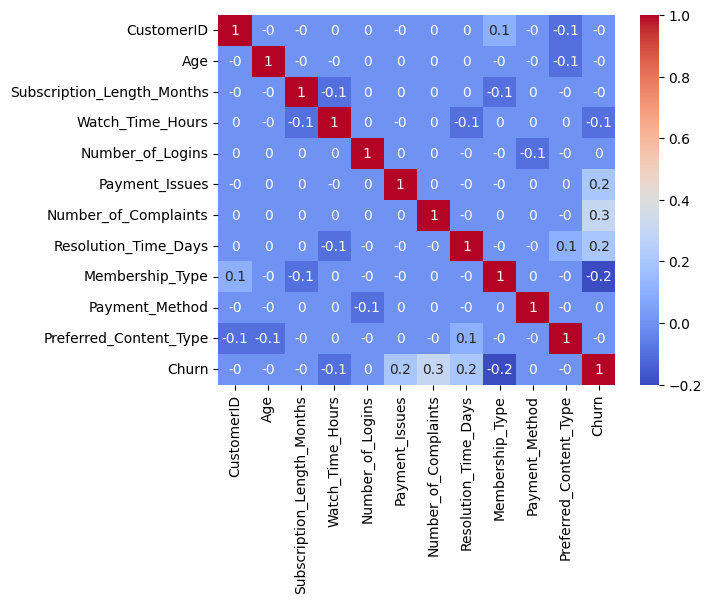

In [ ]:
## Correlation matrix
corr_matrix = cust_churn.corr().round(1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

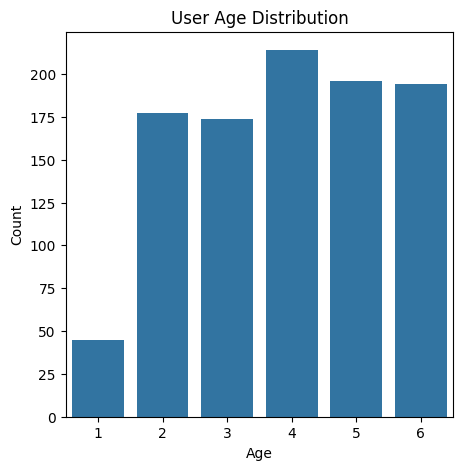

In [ ]:
## Plot User Age Range
plt.figure(figsize=(5, 5))
sns.countplot(x='Age', data=cust_churn)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('User Age Distribution')
plt.show()


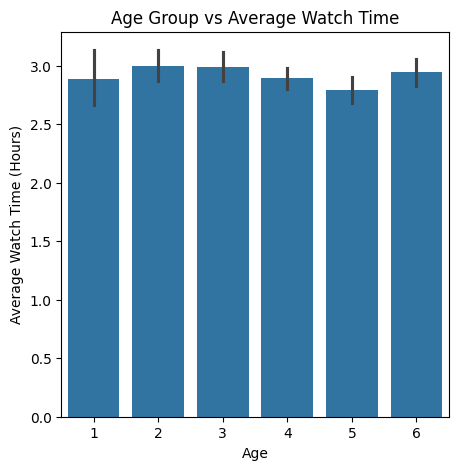

In [ ]:
## Plot graph age vs average watch time hours per age range
plt.figure(figsize=(5, 5))
sns.barplot(x='Age', y='Watch_Time_Hours', data=cust_churn)
plt.xlabel('Age')
plt.ylabel('Average Watch Time (Hours)')
plt.title('Age Group vs Average Watch Time')
plt.show()

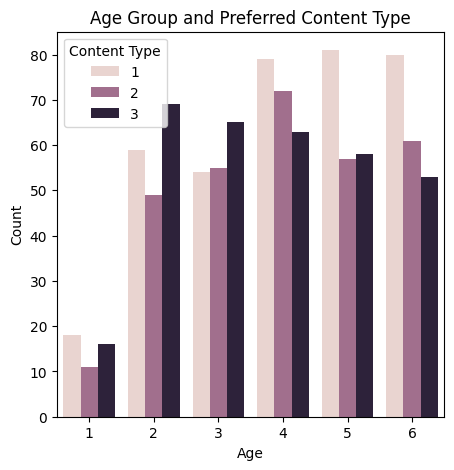

In [ ]:
## Plot Age Group and their preferred content
plt.figure(figsize=(5, 5))
sns.countplot(x='Age', hue='Preferred_Content_Type', data=cust_churn)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Group and Preferred Content Type')
plt.legend(title='Content Type', loc='upper left')
plt.show()


<Figure size 640x480 with 0 Axes>

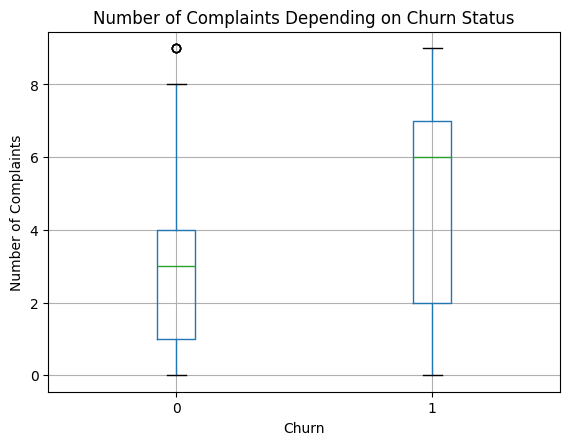

In [ ]:
## Plot Number of Complaints vs Churn probability
plt.figure()
cust_churn.boxplot(column='Number_of_Complaints', by='Churn')
plt.title('Number of Complaints Depending on Churn Status')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Number of Complaints')
plt.show()

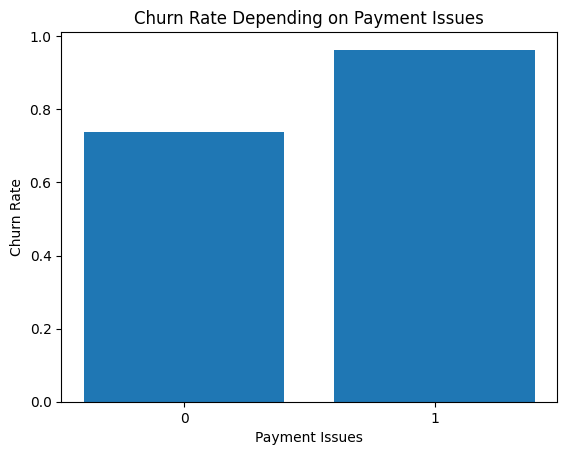

Payment_Issues
0    0.737748
1    0.963265
Name: Churn, dtype: float64


In [ ]:
## Calculate churn rate by payment issues
churn_rate = cust_churn.groupby('Payment_Issues')['Churn'].mean()

## Plot Churn Rate by Payment Issues
plt.figure()
plt.bar(churn_rate.index, churn_rate.values)
plt.xlabel('Payment Issues')
plt.ylabel('Churn Rate')
plt.title('Churn Rate Depending on Payment Issues')
plt.xticks([0, 1])
plt.show()

print(churn_rate)

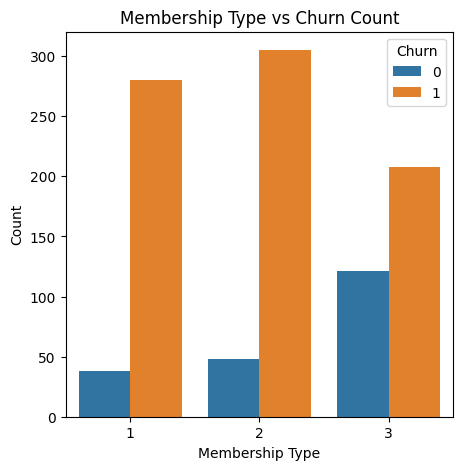

In [ ]:
## Plot Membership Type and Churn Count grouped by Membership Type
plt.figure(figsize=(5, 5))
sns.countplot(x='Membership_Type', hue='Churn', data=cust_churn)
plt.xlabel('Membership Type')
plt.ylabel('Count')
plt.title('Membership Type vs Churn Count')
plt.show()

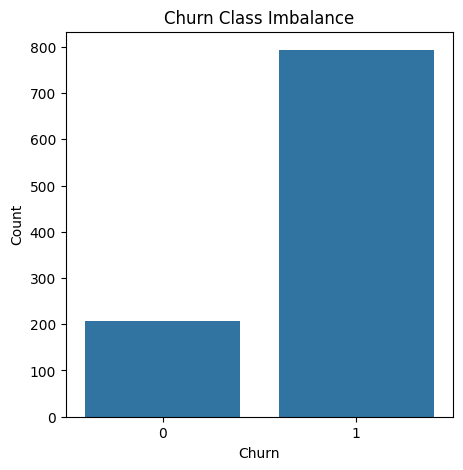

In [ ]:
## Plot Churn Column class imbalance
plt.figure(figsize=(5, 5))
sns.countplot(x='Churn', data=cust_churn)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Churn Class Imbalance')
plt.show()